<a href="https://colab.research.google.com/github/nuhuynhh/AAI2026/blob/main/DVGAI_Module_LabHUYNH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd

col_names = [
    'age','workclass','fnlwgt','education','education-num','marital-status',
    'occupation','relationship','race','sex','capital-gain','capital-loss',
    'hours-per-week','native-country','income'
]

df = pd.read_csv('/content/adult-all-1.csv', header=None, names=col_names)
df.head()

df = df.replace(' ?', pd.NA)   # handles the common " ?" format
df = df.dropna()

In [41]:
df.info()
df.isin(['?']).sum()
import numpy as np

df.replace('?', np.nan, inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  47985 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [11]:
df.isna().sum()
df.dropna(inplace=True)
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
Index: 45221 entries, 0 to 48840
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   39             45221 non-null  int64 
 1   State-gov      45221 non-null  object
 2   77516          45221 non-null  int64 
 3   Bachelors      45221 non-null  object
 4   13             45221 non-null  int64 
 5   Never-married  45221 non-null  object
 6   Adm-clerical   45221 non-null  object
 7   Not-in-family  45221 non-null  object
 8   White          45221 non-null  object
 9   Male           45221 non-null  object
 10  2174           45221 non-null  int64 
 11  0              45221 non-null  int64 
 12  40             45221 non-null  int64 
 13  United-States  45221 non-null  object
 14  <=50K          45221 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.5+ MB


,0
39,int64
State-gov,object
77516,int64
Bachelors,object
13,int64
Never-married,object
Adm-clerical,object
Not-in-family,object
White,object
Male,object


In [12]:
df.describe()

,39,77516,13,2174,0,40
count,45221.000000,4.522100e+04,45221.000000,45221.000000,45221.000000,45221.000000
mean,38.547931,1.897372e+05,10.118396,1101.406625,88.597377,40.938038
std,13.218016,1.056390e+05,2.552873,7506.511388,404.960355,12.007640
min,17.000000,1.349200e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.173920e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783190e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.379280e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [44]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

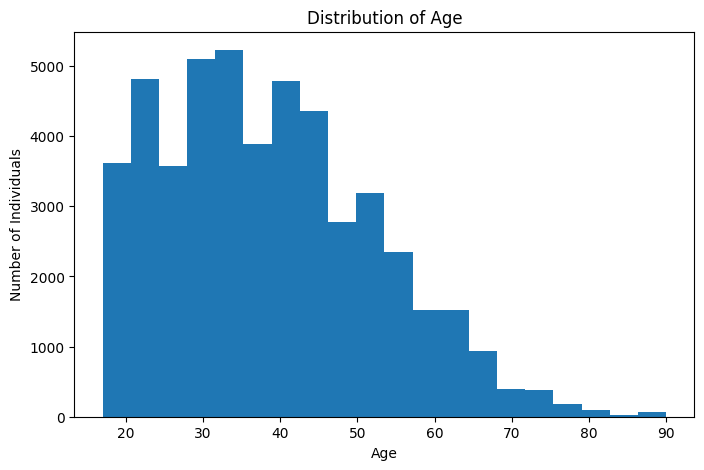

In [43]:
df.columns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=20)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Number of Individuals')
plt.show()

/tmp/ipython-input-530803102.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['<=50K', '>50K'], showfliers=False)


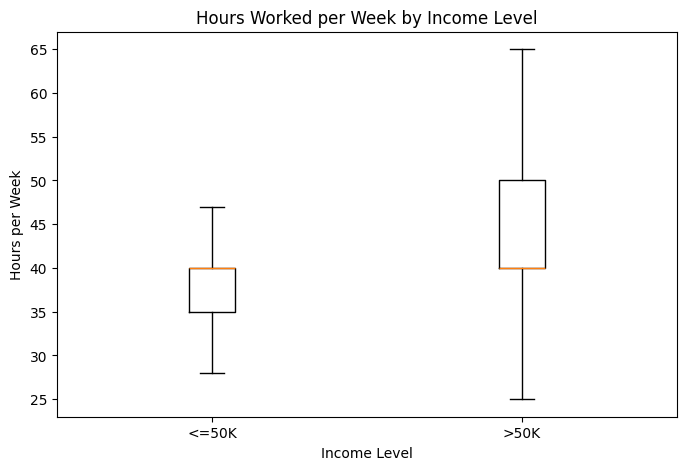

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(data, labels=['<=50K', '>50K'], showfliers=False)
plt.title('Hours Worked per Week by Income Level')
plt.xlabel('Income Level')
plt.ylabel('Hours per Week')
plt.show()

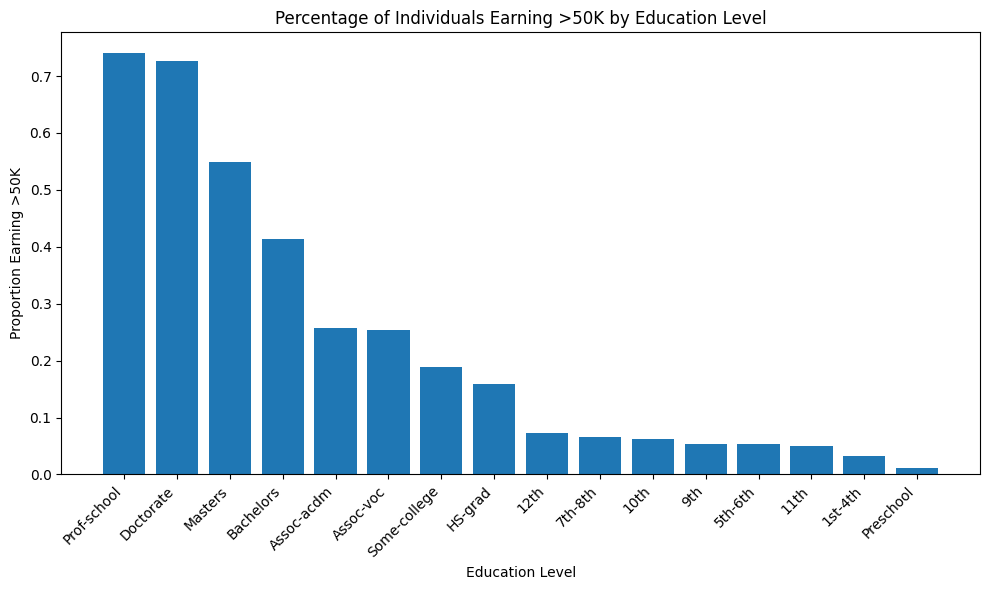

In [36]:
df['education'] = df['education'].str.strip()
# Calculate proportion earning less than >50K by education
edu_income = (
    df.groupby('education')['income']
      .apply(lambda x: (x == '>50K').mean())
      .sort_values(ascending=False)
)

edu_income.head()
import matplotlib.pyplot as plt

df['education'] = df['education'].str.strip()

edu_income = (
    df.groupby('education')['income']
      .apply(lambda x: (x == '>50K').mean())
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
plt.bar(edu_income.index, edu_income.values)
plt.title('Percentage of Individuals Earning >50K by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Proportion Earning >50K')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

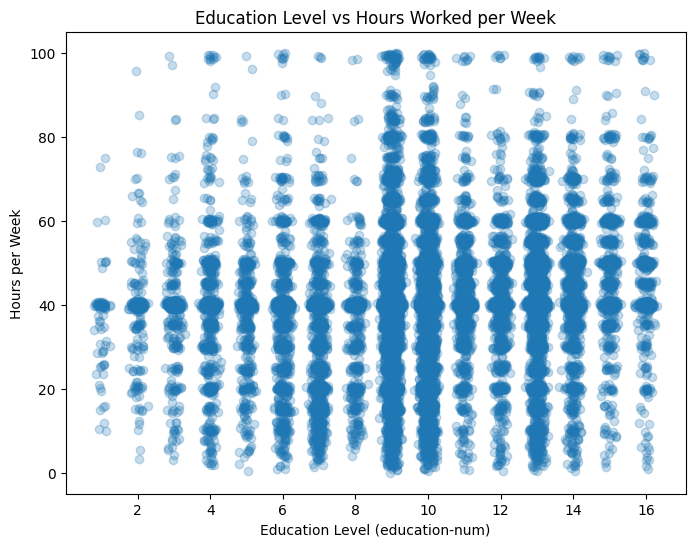

In [46]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    df['education-num'] + np.random.normal(0, 0.1, size=len(df)),
    df['hours-per-week'] + np.random.normal(0, 0.5, size=len(df)),
    alpha=0.25
)
plt.title('Education Level vs Hours Worked per Week')
plt.xlabel('Education Level (education-num)')
plt.ylabel('Hours per Week')
plt.show()

In [47]:
import pandas as pd

edu_income_ct = pd.crosstab(df['education'], df['income'])
edu_income_ct

income,<=50K,>50K
education,,
10th,1302,87
11th,1720,92
12th,609,48
1st-4th,239,8
5th-6th,482,27
7th-8th,893,62
9th,715,41
Assoc-acdm,1188,413
Assoc-voc,1539,522


In [50]:
edu_income_pct = edu_income_ct.div(edu_income_ct.sum(axis=1), axis=0)
edu_income_pct

income,<=50K,>50K
education,,
10th,0.937365,0.062635
11th,0.949227,0.050773
12th,0.926941,0.073059
1st-4th,0.967611,0.032389
5th-6th,0.946955,0.053045
7th-8th,0.935079,0.064921
9th,0.945767,0.054233
Assoc-acdm,0.742036,0.257964
Assoc-voc,0.746725,0.253275


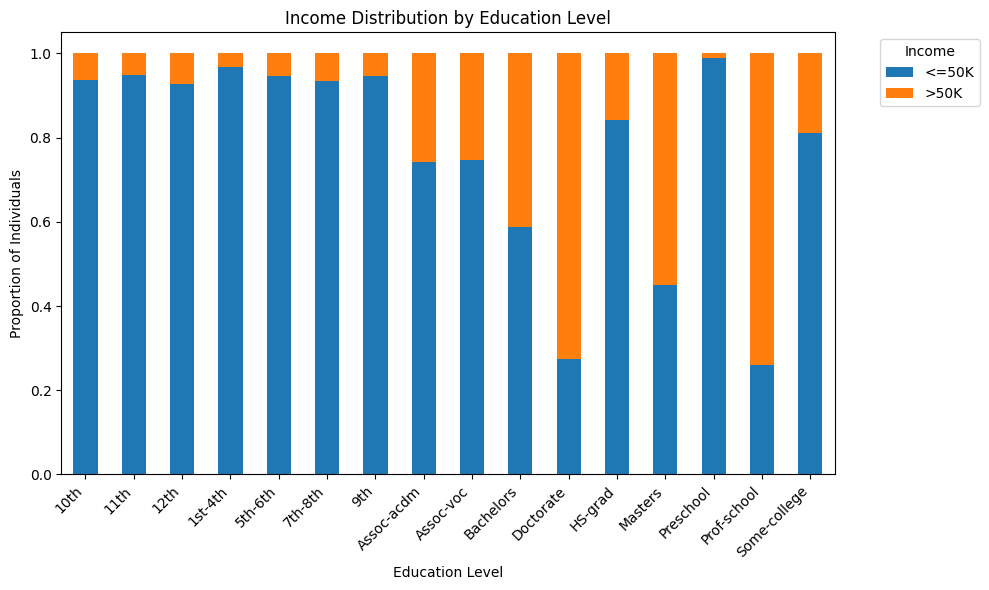

In [51]:
import matplotlib.pyplot as plt

edu_income_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Income Distribution by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Proportion of Individuals')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Income', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()